# Phase 3: Large-Lattice Phase Diagram vs. Onsager

Rebuilds the legacy notebook's `T`-`B` magnetization phase diagram using the
validated (Phase 1-2) periodic-boundary engine: `ising.run_sweeps` (with its
anti-trap safety net), autocorrelation-aware burn-in detection and error
bars from `sampling.py`, instead of the legacy's free (zero-padded)
boundary conditions and fixed 1000-sweep/400-sample protocol.

Two measurements, both at `L=32`:

1. A fine `B=0` temperature sweep, compared directly against Onsager's
   exact `T_c` and magnetization curve -- the actual validation gate.
2. A coarser `T`-`B` grid reproducing the legacy notebook's 2D phase
   diagram visualization.

Both were computed by `compute_phase3.py` (saved to `.npz` since the full
sweep takes several minutes on CPU) and are just loaded and plotted here.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import analytic

b0 = np.load('phase3_B0.npz')
grid = np.load('phase3_grid.npz')
T_values, E_means, E_sems, M_means, M_sems = (b0[k] for k in
    ['T_values', 'E_means', 'E_sems', 'M_means', 'M_sems'])
T_grid, B_grid, M_grid = grid['T_grid'], grid['B_grid'], grid['M_grid']
L = int(b0['L'])
T_c = analytic.onsager_Tc()
print(f'L={L}, Onsager Tc={T_c:.4f}')

L=32, Onsager Tc=2.2692


## B=0: magnetization and energy vs. Onsager

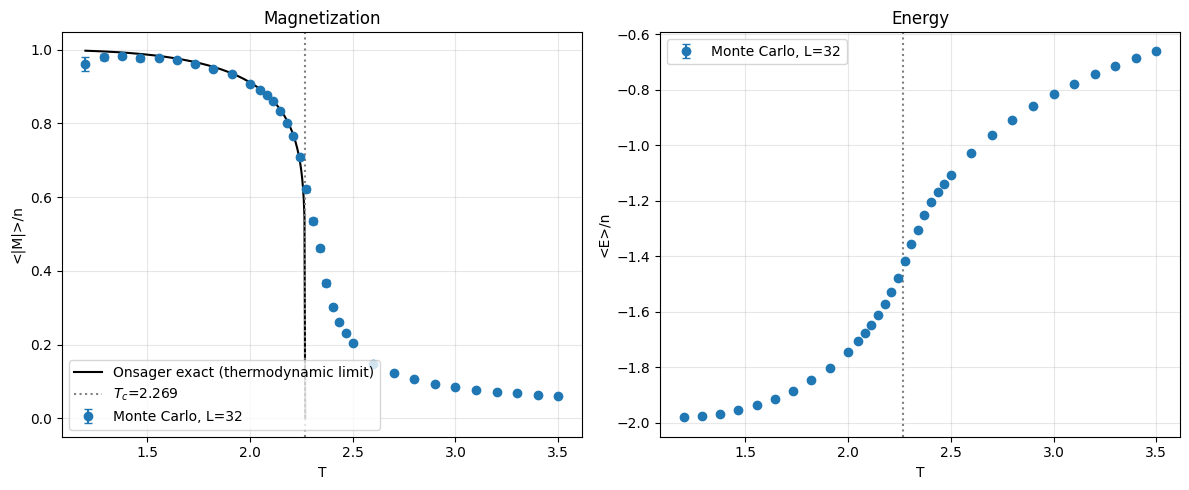

In [2]:
T_fine = np.linspace(T_values.min(), T_c, 300)
m_exact = analytic.onsager_magnetization(T_fine)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
ax.errorbar(T_values, M_means, yerr=M_sems, fmt='o', capsize=3, label=f'Monte Carlo, L={L}')
ax.plot(T_fine, m_exact, 'k-', label='Onsager exact (thermodynamic limit)')
ax.axvline(T_c, color='gray', ls=':', label=f'$T_c$={T_c:.3f}')
ax.set_xlabel('T'); ax.set_ylabel('<|M|>/n'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Magnetization')

ax = axes[1]
ax.errorbar(T_values, E_means, yerr=E_sems, fmt='o', capsize=3, label=f'Monte Carlo, L={L}')
ax.axvline(T_c, color='gray', ls=':')
ax.set_xlabel('T'); ax.set_ylabel('<E>/n'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Energy')

fig.tight_layout()
fig.savefig('media/phase3_onsager_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [3]:
# Quantitative check: below Tc, MC magnetization should be close to the exact
# curve up to finite-size rounding of the transition; above Tc it should be
# small (residual finite-size magnetization, not zero, since L=32 is finite).
below = T_values < T_c - 0.15
above = T_values > T_c + 0.15
m_exact_below = analytic.onsager_magnetization(T_values[below])
resid_below = M_means[below] - m_exact_below
print(f'Below Tc (T < Tc-0.15): mean |MC - exact| = {np.abs(resid_below).mean():.4f}, '
      f'max = {np.abs(resid_below).max():.4f}  (finite-size L={L} rounds the transition, '
      f'so some deviation approaching Tc is expected)')
print(f'Above Tc (T > Tc+0.15): mean <|M|>/n = {M_means[above].mean():.4f} '
      f'(small residual finite-size magnetization, not exactly zero, as expected for finite L)')
assert np.abs(resid_below).mean() < 0.15, 'MC magnetization deviates too far from Onsager well below Tc'
assert M_means[above].mean() < 0.35, 'MC magnetization above Tc is too large -- transition looks smeared out badly'
print('PASS: magnetization curve tracks the Onsager result below Tc and drops to a small residual above it.')

Below Tc (T < Tc-0.15): mean |MC - exact| = 0.0079, max = 0.0348  (finite-size L=32 rounds the transition, so some deviation approaching Tc is expected)
Above Tc (T > Tc+0.15): mean <|M|>/n = 0.1228 (small residual finite-size magnetization, not exactly zero, as expected for finite L)
PASS: magnetization curve tracks the Onsager result below Tc and drops to a small residual above it.


## Full T-B phase diagram

Coarser grid (fewer replicas/sweeps -- this panel is a qualitative
visualization, the quantitative check is the B=0 sweep above).

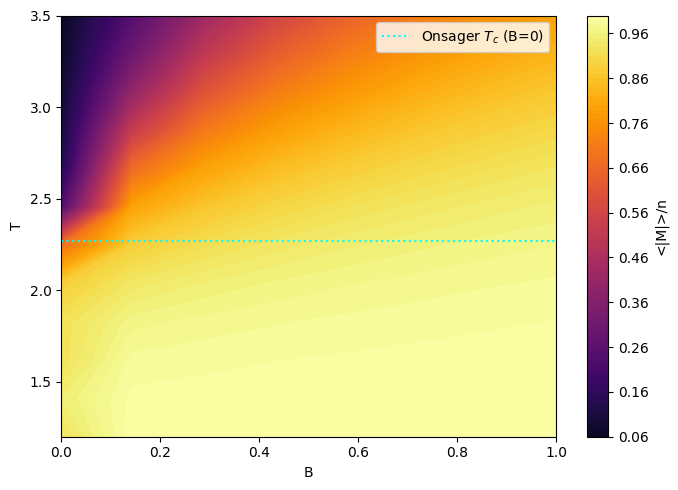

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
cont = ax.contourf(B_grid, T_grid, M_grid.T, levels=100, cmap='inferno', vmin=0, vmax=1)
ax.axhline(T_c, color='cyan', ls=':', label=f'Onsager $T_c$ (B=0)')
ax.set_xlabel('B'); ax.set_ylabel('T')
ax.legend()
plt.colorbar(cont, ax=ax, label='<|M|>/n')
fig.tight_layout()
fig.savefig('media/phase3_phase_diagram.png', dpi=150, bbox_inches='tight')
plt.show()